
Fe (α)
  Number of atoms in unit cell : 2
  Lattice parameter            : 2.870 Å
  Volume                       : 23.640 Å³
  Sites                        : [PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Fe (1.435, 1.435, 1.435) [0.5, 0.5, 0.5]]

Fe (γ)
  Number of atoms in unit cell : 4
  Lattice parameter            : 3.656 Å
  Volume                       : 48.867 Å³
  Sites                        : [PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Fe (1.828, 1.828, 0.0) [0.5, 0.5, 0.0], PeriodicSite: Fe (1.828, 0.0, 1.828) [0.5, 0.0, 0.5], PeriodicSite: Fe (0.0, 1.828, 1.828) [0.0, 0.5, 0.5]]

Fe (δ)
  Number of atoms in unit cell : 2
  Lattice parameter            : 2.930 Å
  Volume                       : 25.154 Å³
  Sites                        : [PeriodicSite: Fe (0.0, 0.0, 0.0) [0.0, 0.0, 0.0], PeriodicSite: Fe (1.465, 1.465, 1.465) [0.5, 0.5, 0.5]]

Ni
  Number of atoms in unit cell : 4
  Lattice parameter            : 3.524 Å
  Volume     

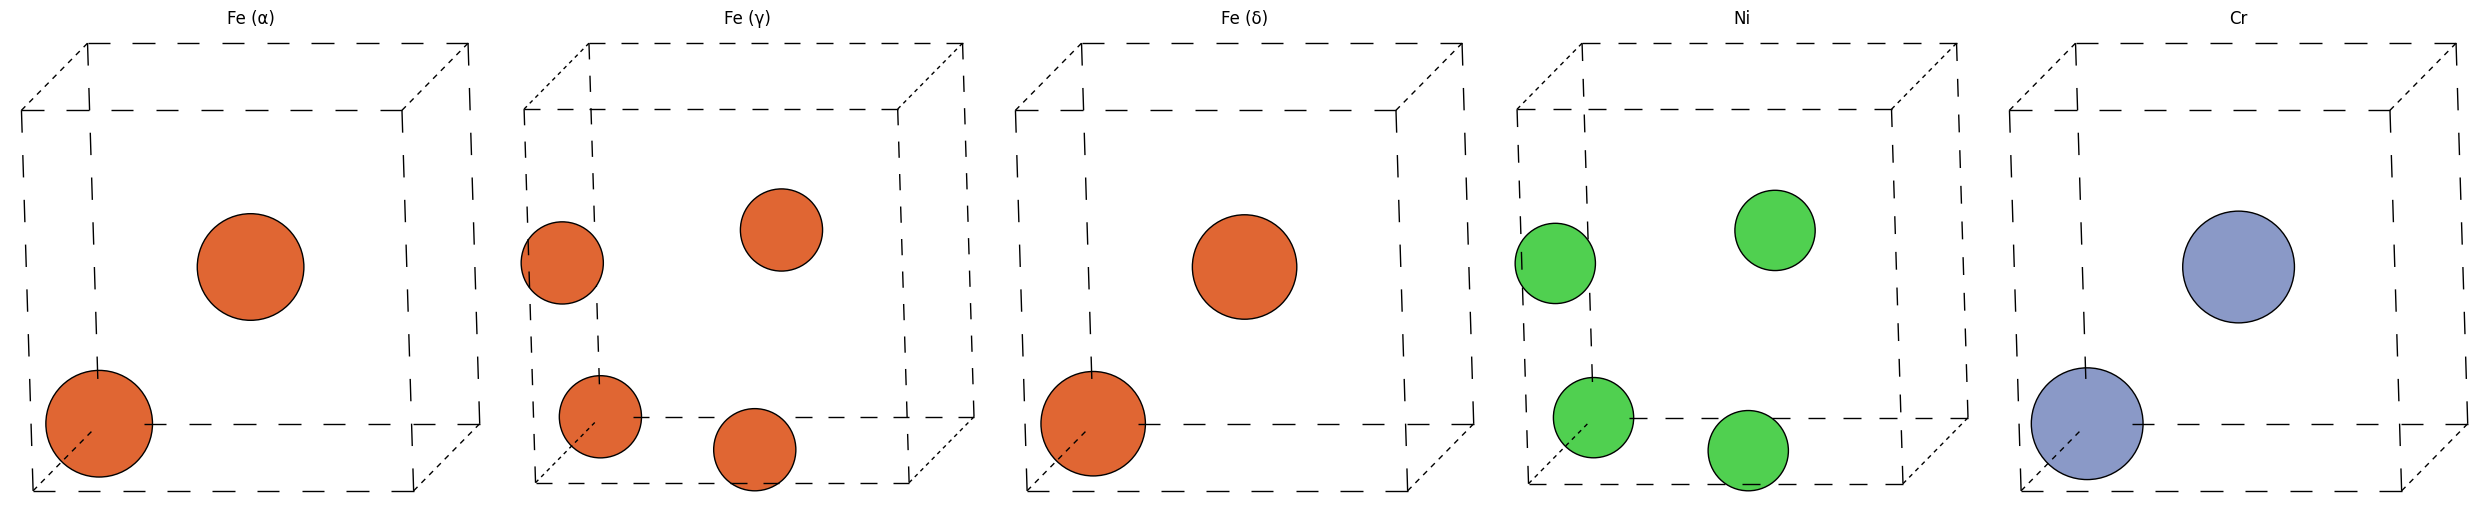

0 Fe + 16 Cr | lattice_a = 2.884 Å
4 Fe + 12 Cr | lattice_a = 2.880 Å
8 Fe + 8 Cr | lattice_a = 2.877 Å
12 Fe + 4 Cr | lattice_a = 2.873 Å
16 Fe + 0 Cr | lattice_a = 2.870 Å
0 Fe + 16 Ni | lattice_a = 3.524 Å
4 Fe + 12 Ni | lattice_a = 3.361 Å
8 Fe + 8 Ni | lattice_a = 3.197 Å
12 Fe + 4 Ni | lattice_a = 3.034 Å
16 Fe + 0 Ni | lattice_a = 2.870 Å
0 Cr + 16 Ni | lattice_a = 3.524 Å
4 Cr + 12 Ni | lattice_a = 3.364 Å
8 Cr + 8 Ni | lattice_a = 3.204 Å
12 Cr + 4 Ni | lattice_a = 3.044 Å
16 Cr + 0 Ni | lattice_a = 2.884 Å


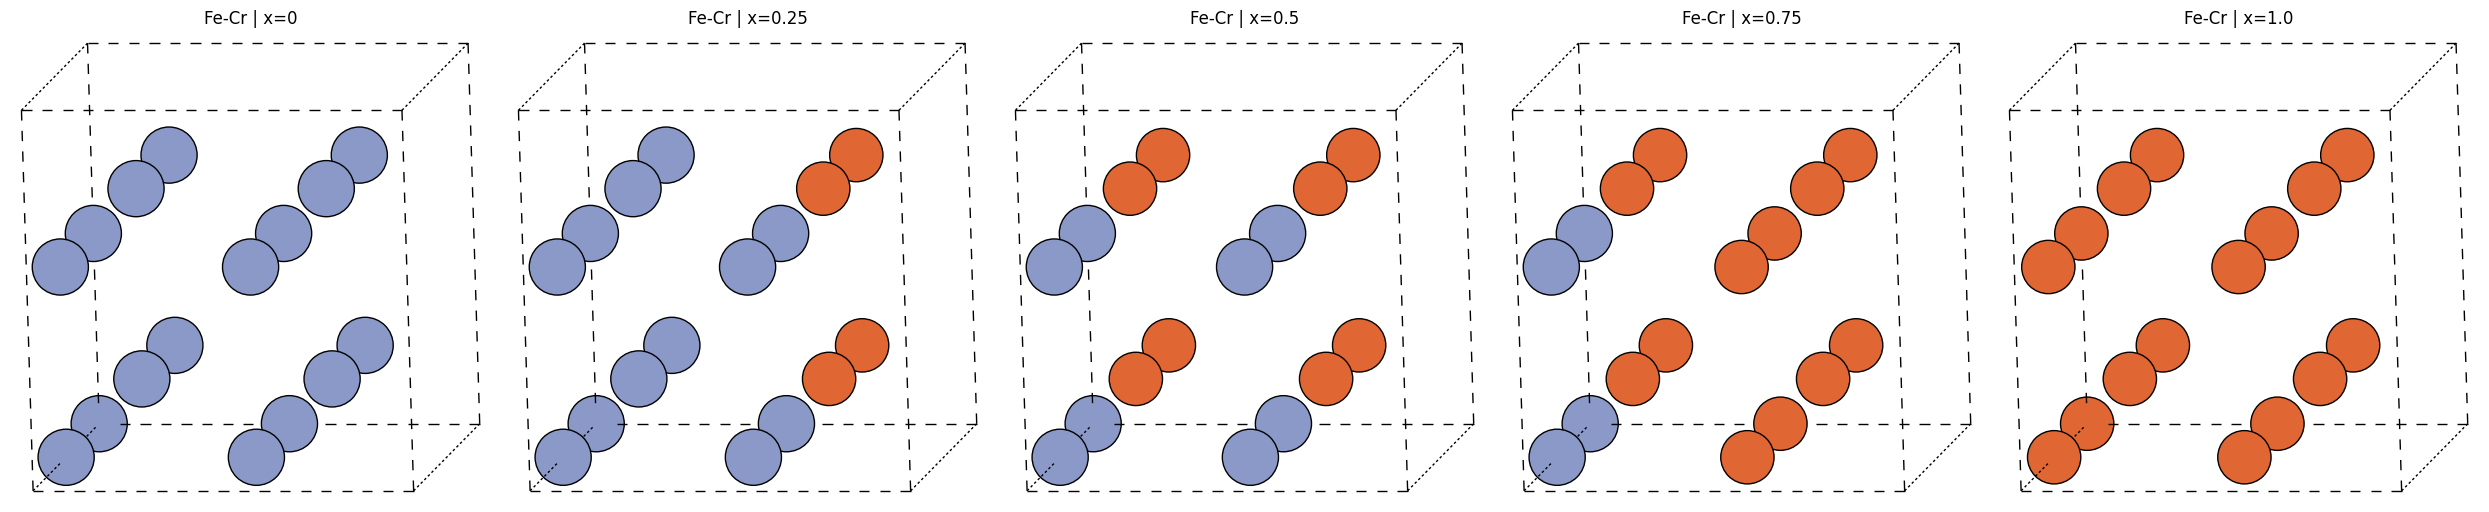

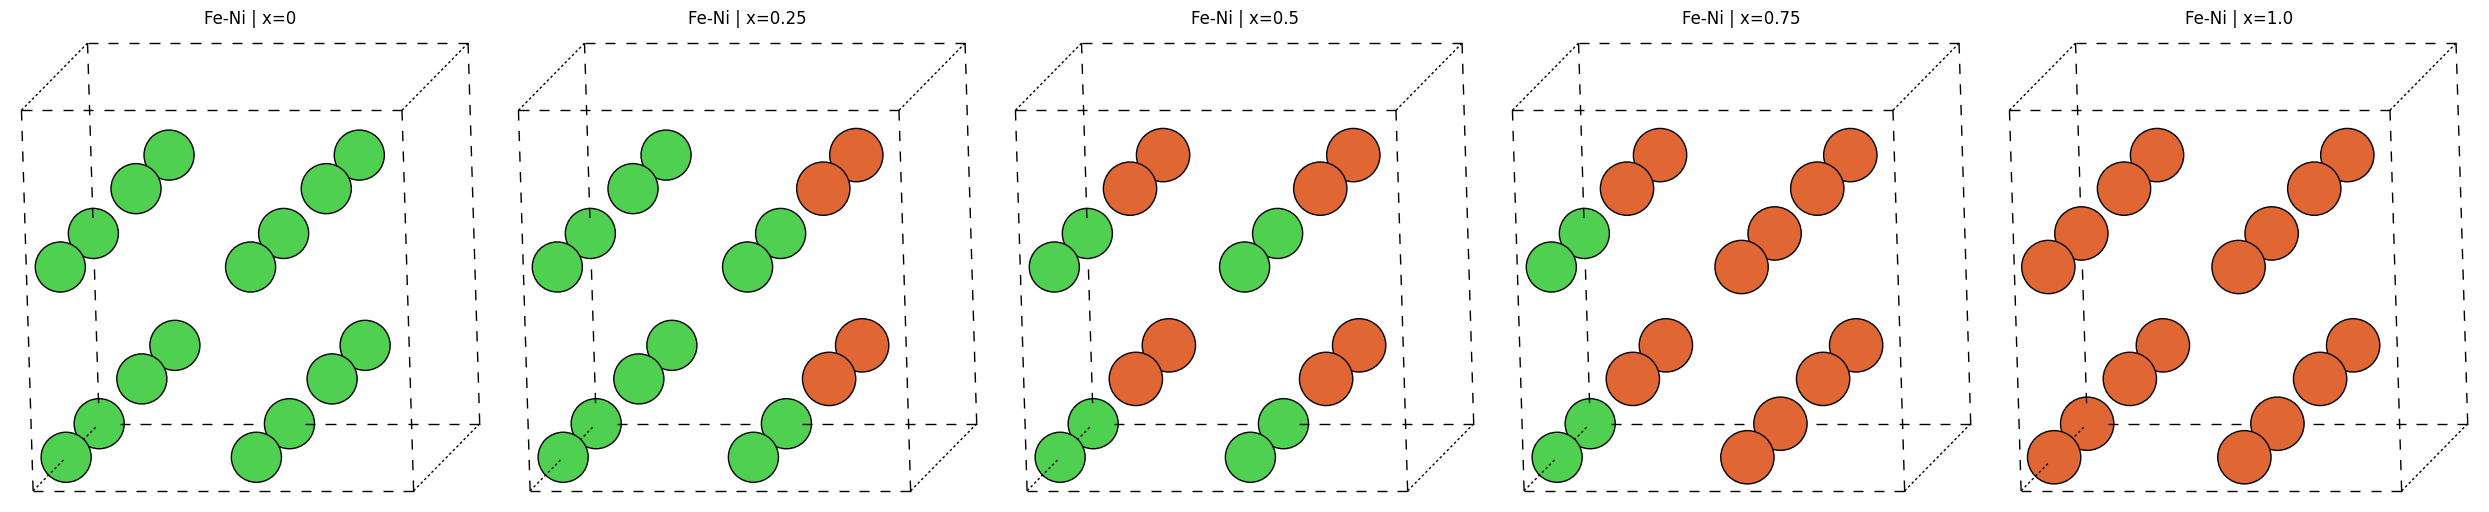

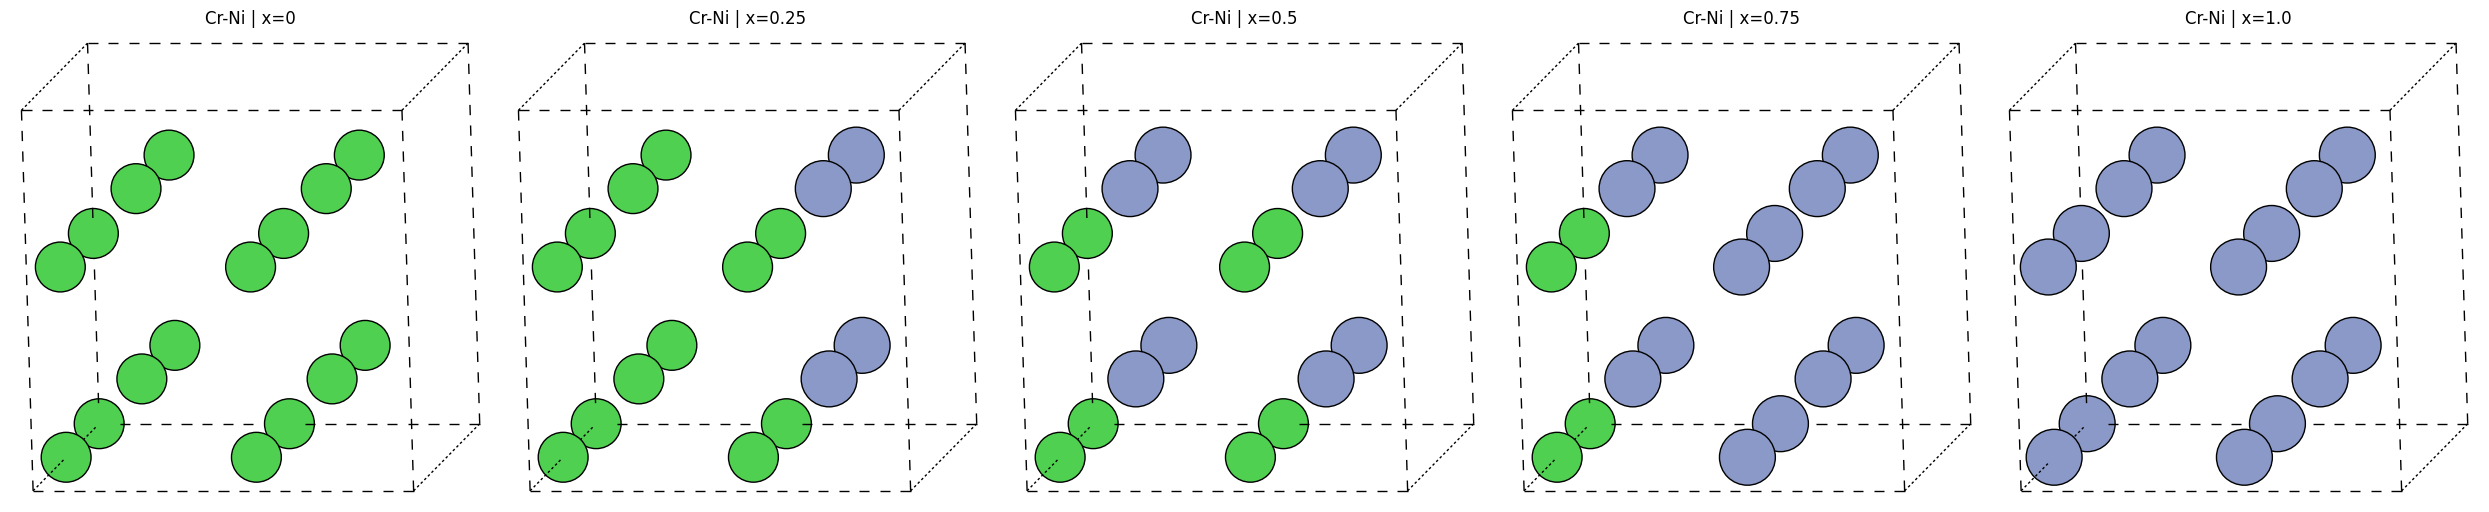

12 Fe + 1 Cr + 1 Ni | lattice_a = 2.937 Å
9 Fe + 3 Cr + 3 Ni | lattice_a = 3.004 Å
5 Fe + 5 Cr + 5 Ni | lattice_a = 3.090 Å
1 Fe + 12 Cr + 1 Ni | lattice_a = 2.947 Å
1 Fe + 1 Cr + 12 Ni | lattice_a = 3.395 Å


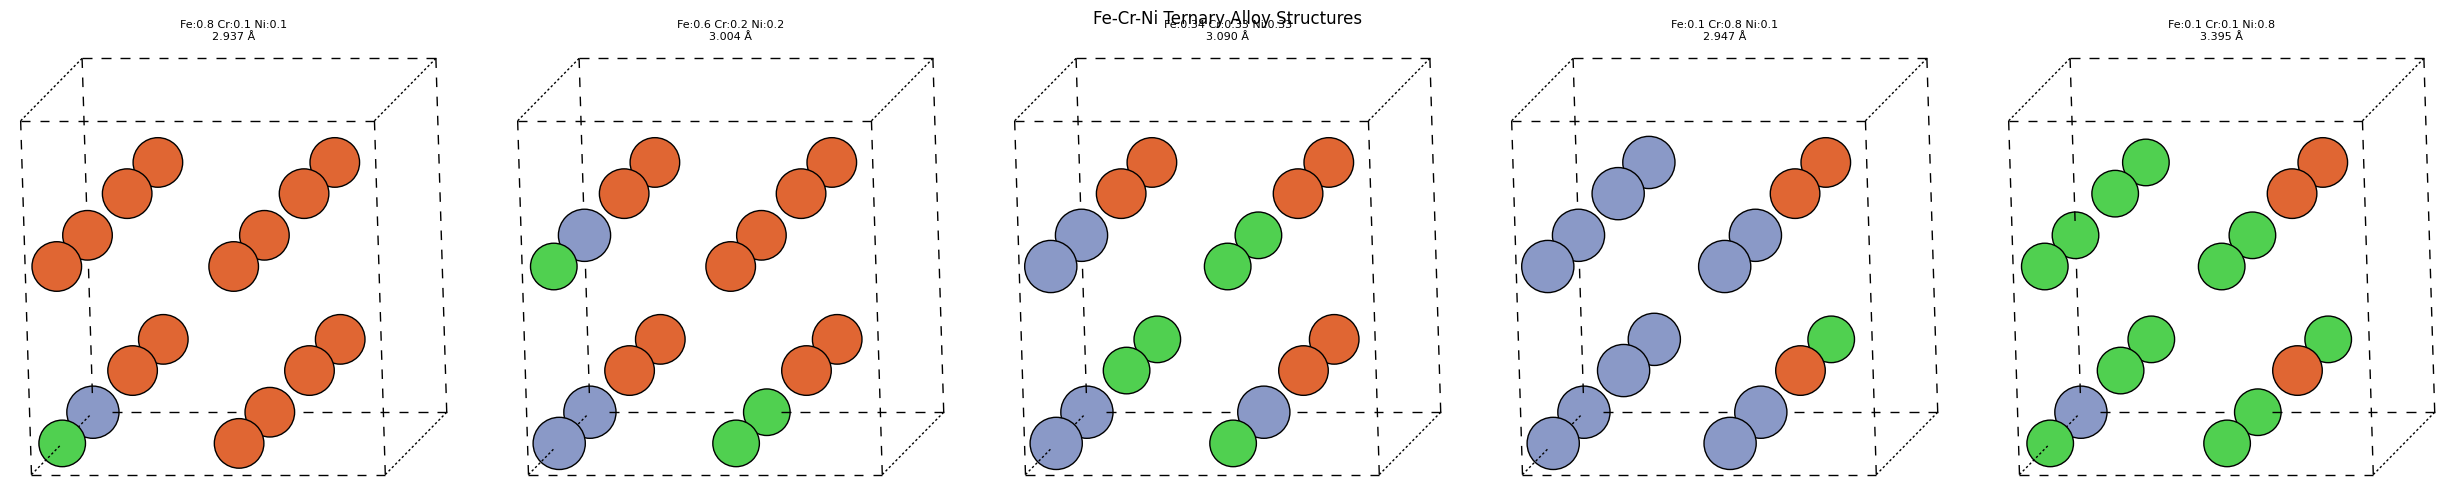

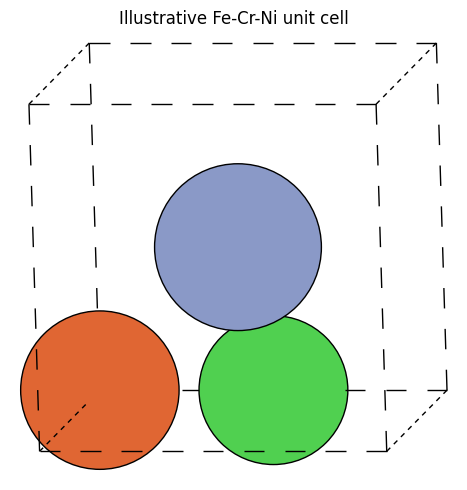

In [ ]:
from ase.build import bulk
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
import numpy as np
from pymatgen.core import Structure, Lattice, Element, Composition
from pymatgen.io.ase import AseAtomsAdaptor
# Structure = the full crystal (lattice + atoms)
# Lattice   = defines the unit cell box (size and shape)
# Element, Composition = tools for working with elements and alloy compositions


# ── UNARY: SINGLE ELEMENTS ───────────────────────────────────────────────────

# Build FCC Nickel using pymatgen
ni = Structure.from_spacegroup("Fm-3m", Lattice.cubic(3.524), ["Ni"], [[0, 0, 0]])
# "Fm-3m": FCC space group, a=3.524 Å

# Build BCC Iron using pymatgen
fe_alpha = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.870), ["Fe"], [[0, 0, 0]])
# "Im-3m": BCC space group, a=2.870 Å when fe is below 912 °C (alpha-Fe)

fe_gamma = Structure.from_spacegroup("Fm-3m", Lattice.cubic(3.656), ["Fe"], [[0, 0, 0]])
# "Fm-3m": FCC space group, a=3.656 Å when fe is above 912 °C (gamma-Fe) and below 1394 °C (delta-Fe)

fe_delta = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.930), ["Fe"], [[0, 0, 0]])
# "Im-3m" Bcc space group, a=2.930 Å when fe is above 1394 °C (delta-Fe)

# Build BCC Chromium using pymatgen
cr = Structure.from_spacegroup("Im-3m", Lattice.cubic(2.884), ["Cr"], [[0, 0, 0]])
# from_spacegroup: builds full crystal using symmetry rules, no need to type every atom
# Lattice.cubic(2.884): defines unit cell box, all sides 2.884 Å, all angles 90°
# ["Cr"]: element placed at the starting position
# [[0,0,0]]: one unique atom position, pymatgen uses Im-3m symmetry to auto-generate
#            the body-centre atom at [0.5, 0.5, 0.5]

structures = [
    ("Fe (α)", fe_alpha),
    ("Fe (γ)", fe_gamma),
    ("Fe (δ)", fe_delta),
    ("Ni",     ni),
    ("Cr",     cr),
]

for name, structure in structures:
    print(f"\n{name}")
    print(f"  Number of atoms in unit cell : {len(structure)}")
    print(f"  Lattice parameter            : {structure.lattice.a:.3f} Å")
    print(f"  Volume                       : {structure.volume:.3f} Å³")
    print(f"  Sites                        : {structure.sites}")
# loops through all 5 print statements for each individual structure

# ── VISUALISATION ─────────────────────────────────────────────────────────────

adaptor = AseAtomsAdaptor()
# Converts pymatgen Structure → ASE Atoms so plot_atoms can render them

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
# 1 row, 5 columns — one subplot per structure

for ax, (name, structure) in zip(axes, structures):
    ase_atoms = adaptor.get_atoms(structure)
    plot_atoms(ase_atoms, ax, radii=0.3, rotation="10x,-10y,0z")
    ax.set_title(name)
# loops through all 5 structures and plots each one

plt.tight_layout()
plt.show()

# Shows the atom positions within one unit cell
# Corner atoms appear as full circles but are shared across 8 neighbouring unit cells (each cell owns 1/8)
# Face atoms are shared across 2 neighbouring unit cells (each cell owns 1/2)
# The visualisation shows position only, not fractional ownership

#── BINARY: TWO-ELEMENT ALLOYS ───────────────────────────────────────────────

# Note: all compositions built on element1 base structure
# In reality Fe-Ni transitions from BCC to FCC with increasing Ni content
# This transition is captured in the CALPHAD phase diagram


# Build BCC Fe-Cr alloy using pymatgen
Lattice_params = {
    "Fe": 2.870,
    "Ni": 3.524,
    "Cr": 2.884
}

space_group = {
    "Fe": "Im-3m",
    "Ni": "Fm-3m",
    "Cr": "Im-3m"
}


def alloy(element1, element2):
    
    composition = [ 0, 0.25, 0.5, 0.75, 1.0]
    structure = Structure.from_spacegroup(space_group[element1], Lattice.cubic(lattice_params[element1]), [element1], [[0, 0, 0]])
    
    n_atoms = len(structure.make_supercell([2, 2, 2]))
    n_element1 = [int(n_atoms * x) for x in composition]

    alloy_results = []

    for x, n1, n2 in zip(composition, n_element1, [n_atoms - n for n in n_element1]):
     try:
        structure = Structure.from_spacegroup(space_group[element1], Lattice.cubic(lattice_params[element1]), [element1], [[0, 0, 0]])
        supercell = structure.make_supercell([2, 2, 2])
        for i in range(n2):
            supercell.replace(i, element2)
        lattice_a_vegard = Lattice_params[element1] * x + Lattice_params[element2] * (1 - x)
        alloy_results.append({
            "system": f"{element1}-{element2}",
            "composition_x": x,
            f"n_{element1}": n1,
            f"n_{element2}": n2,
            "structure": supercell,
            "lattice_a_vegard": lattice_a_vegard
        })
        print(f"{n1} {element1} + {n2} {element2} | lattice_a = {lattice_a_vegard:.3f} Å")
     except Exception as e:
         print(f"Error at x={x}: {e}")

    return alloy_results

fe_cr_results = alloy("Fe", "Cr")
fe_ni_results = alloy("Fe", "Ni")
cr_ni_results = alloy("Cr", "Ni")

#dictionary a recall button so if i recall Fe i get 2.870 this differ from a list because i can select individual values from a dictionary,
#  while also being able to assign the whole dictionary to a variable and not needing to remember where what variable is, e.g lattice_params["Fe"] gives 2.870,
#  while if i had a list i would need to remember that Fe is the first element and do lattice_params[0] to get the same value

#structure gets each metal one at a time and builds the supercell
#n_atom is the total number of atoms in the supercell, must be a function of len as fcc and bcc have different number of atoms
#n_element is the number of atoms of each element in the alloy, calculated from the composition and total number of atoms
#alloy results is a list of dictionaties with all the relevant information for each alloy composition written below it

#zip allows us to loop through multiple lists in parallel
#try except block to catch any errors that may arise during the alloy generation process
#range(n2) runs the loop from composition of 0 to 1
#replace replaces the first n2 atoms in the supercell with element2, creating the allot structure
#lattice_a_vegard calculates the lattice parameter of the alloy using Vegard's law, which is a linear interpolation between the lattice parameters of the pure elements based on their composition

for system_results in [fe_cr_results, fe_ni_results, cr_ni_results]:
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    for ax, result in zip(axes, system_results):
        ase_atoms = adaptor.get_atoms(result["structure"])
        plot_atoms(ase_atoms, ax, radii=0.3, rotation="10x,-10y,0z")
        ax.set_title(f"{result['system']} | x={result['composition_x']}")
    
    plt.tight_layout()
    plt.show()

#--------------Ternary: Three element alloys──────────────────────────────────────────────
Lattice_params = {
    "Fe": 2.870,
    "Ni": 3.524,
    "Cr": 2.884
}

space_group = {
    "Fe": "Im-3m",
    "Ni": "Fm-3m",
    "Cr": "Im-3m"
}

def ternary_alloy(element1, element2, element3):
    
    compositions = [
    (0.8, 0.1, 0.1),
    (0.6, 0.2, 0.2),
    (0.34, 0.33, 0.33),
    (0.1, 0.8, 0.1),
    (0.1, 0.1, 0.8),
    ]
    structure = Structure.from_spacegroup(space_group[element1], Lattice.cubic(Lattice_params[element1]), [element1], [[0, 0, 0]])
    n_atoms = len(structure.make_supercell([2, 2, 2]))

    n_element1 = [int(n_atoms * x1)for x1, x2, x3 in compositions]
    n_element2 = [int(n_atoms * x2) for x1, x2, x3 in compositions]
    n_element3 = [int(n_atoms * x3) for x1, x2, x3 in compositions]

    alloy_results = []

    for (x1, x2, x3), n1, n2, n3 in zip(compositions, n_element1, n_element2, n_element3):
        try:
            structure = Structure.from_spacegroup(space_group[element1], Lattice.cubic(Lattice_params[element1]), [element1], [[0, 0, 0]])
            supercell = structure.make_supercell([2, 2, 2])

            for i in range(n2):
                supercell.replace(i, element2)

            for i in range(n2, n2 + n3):
                    supercell.replace(i, element3)

            lattice_a_vegard = Lattice_params[element1] * x1 + Lattice_params[element2] * x2 + Lattice_params[element3] * x3

            alloy_results.append({
            "system": f"{element1}-{element2}-{element3}",
            "composition_x": (x1, x2, x3),
            f"n_{element1}": n1,
            f"n_{element2}": n2,
            f"n_{element3}": n3,
            "structure": supercell,
            "lattice_a_vegard": lattice_a_vegard
            })
            print(f"{n1} {element1} + {n2} {element2} + {n3} {element3} | lattice_a = {lattice_a_vegard:.3f} Å")
        except Exception as e:
            print(f"Error at composition {x1}, {x2}, {x3}: {e}")
            
    return alloy_results

fe_cr_ni_results = ternary_alloy("Fe", "Cr", "Ni")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
# 1 row, 5 columns — one subplot per composition

for ax, result in zip(axes, fe_cr_ni_results):
    ase_atoms = adaptor.get_atoms(result["structure"])
    # Converts each structure to ASE format

    plot_atoms(ase_atoms, ax, radii=0.3, rotation="10x,-10y,0z")
    # Draws the atoms, radii controls size, rotation gives 3D perspective

    x1, x2, x3 = result["composition_x"]
    ax.set_title(f"Fe:{x1} Cr:{x2} Ni:{x3}\n{result['lattice_a_vegard']:.3f} Å", fontsize=8)
    # Title shows composition fractions and predicted lattice parameter

plt.suptitle("Fe-Cr-Ni Ternary Alloy Structures", fontsize=12)
# Overall title for the figure

plt.tight_layout()
plt.show()
#This follows the same pattern as the binary visualisation, one plot per composition, with the title showing the exact Fe/Cr/Ni fractions and the Vegard's law lattice parameter for each composition.
            
# Single illustrative unit cell showing all three elements
lattice = Lattice.cubic(2.937)

species = ["Fe", "Cr", "Ni"]
coords = [
    [0.0, 0.0, 0.0],
    [0.5, 0.5, 0.5],
    [0.5, 0.0, 0.0],
]

structure = Structure(lattice, species, coords)

# Visualise
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ase_atoms = adaptor.get_atoms(structure)
plot_atoms(ase_atoms, ax, radii=0.5, rotation="10x,-10y,0z")
ax.set_title("Illustrative Fe-Cr-Ni unit cell")
plt.tight_layout()
plt.show()

#(x1, x2, x3) = compositions uses a tuple
